In [2]:
import pickle
with open("ssl_features.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())


dict_keys(['features', 'labels'])


In [2]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.0 MB 21.0 MB/s eta 0:00:01
   ---------------------------------------  10.7/11.0 MB 30.5 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 29.8 MB/s  0:00:00
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/4 [pytz]
   ---------------------------------------- 0/4 [pytz]
   ---------- ----------------------------- 1/4 [tzdata]
   ---------- ----------------------------- 1/4 [tzdata]
   -------------------- ------------------- 2/4 [pandas]
   -------------------- ------------------- 2/4 [pa

Feature matrix: (1000, 128)
Label vector: (1000,)

--- Statistical Summary ---
Average Variance: 0.0010
Average Kurtosis: 0.0010


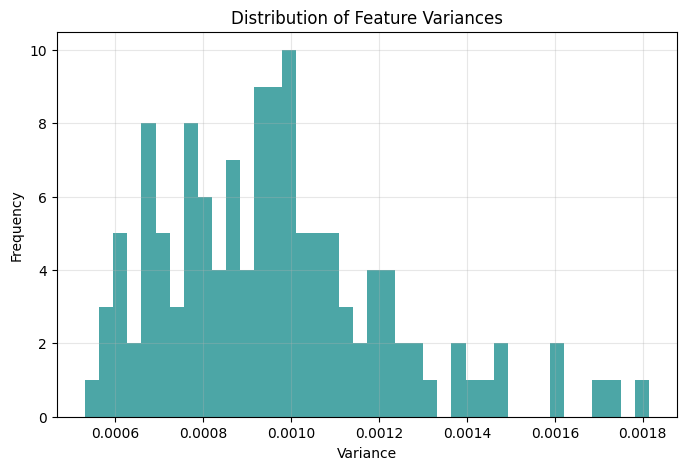


Latent RGB energy distribution: [0.00909155, 0.0059061996, 0.008411238]


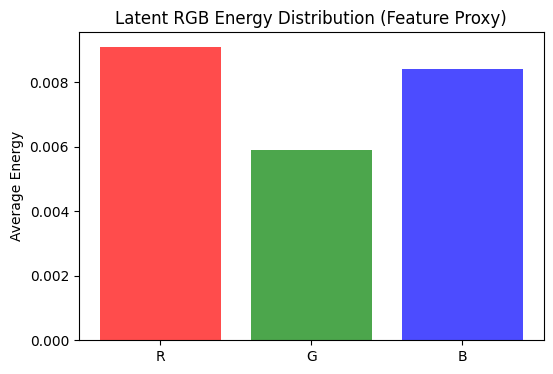


Frequency energy proxy: 0.8819
Spectral entropy: 0.0116

Wavelet Energy — Approx: 0.0694, Detail: 0.0724


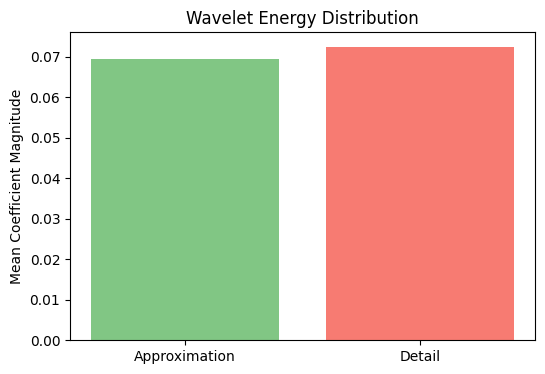


Average Intra-class Distance: 0.4535
Average Inter-class Distance: 0.5123


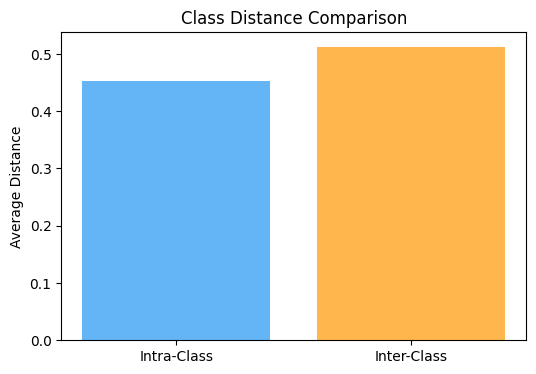

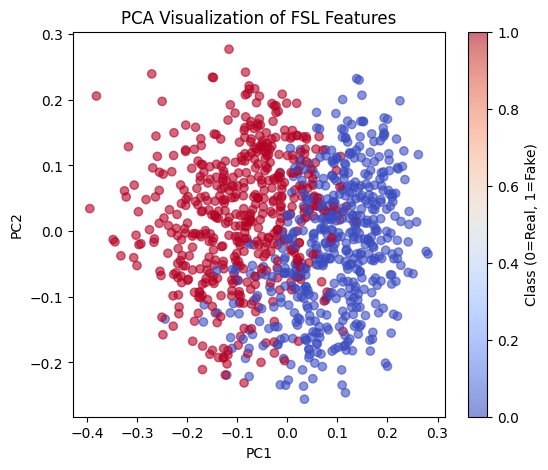

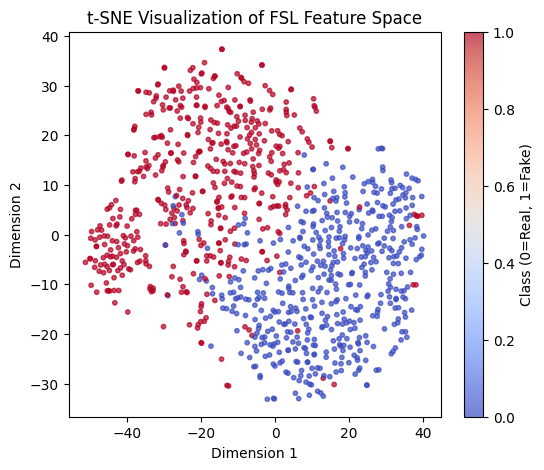


Top 10 Discriminative Feature Indices: [ 67  41  71 116   4  25 104   5  33  64]


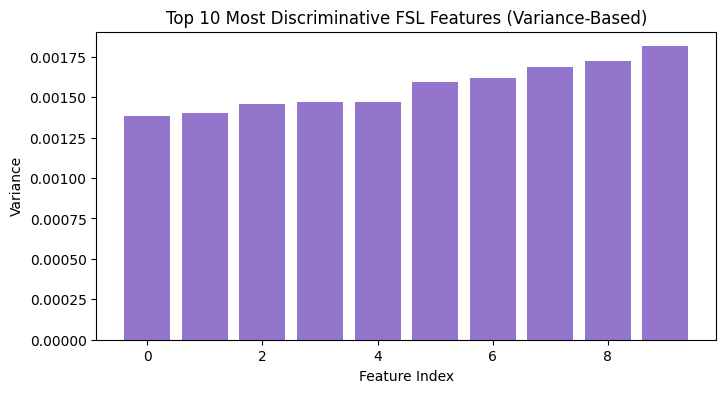


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.92      0.93      0.93       500
           1       0.93      0.92      0.92       500

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.92      1000
weighted avg       0.93      0.93      0.92      1000

Confusion Matrix:
 [[467  33]
 [ 42 458]]


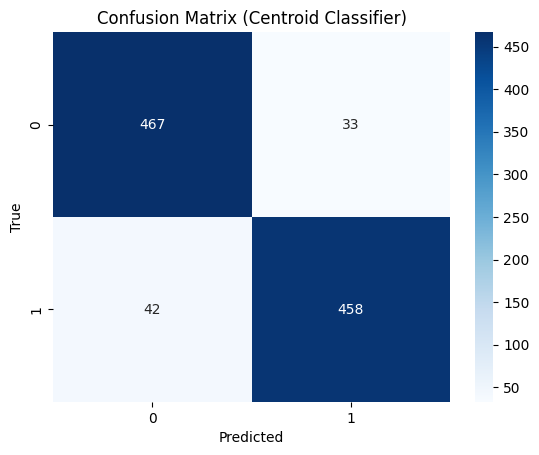

In [4]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances, confusion_matrix, classification_report, accuracy_score
from scipy.stats import kurtosis, skew
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.fft import fft
import pywt
import seaborn as sns

# -------------------------------
# 1. Load SSL Features
# -------------------------------
with open("fsl_features.pkl", "rb") as f:
    data = pickle.load(f)

X = np.array(data["features"])
y = np.array(data["labels"])

print("Feature matrix:", X.shape)
print("Label vector:", y.shape)

# -------------------------------
# 2. Feature-Level Statistics
# -------------------------------
def feature_statistics(X):
    mean = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    skewness = skew(X, axis=0)
    kurt = kurtosis(X, axis=0)
    return {"mean": mean, "variance": var, "skewness": skewness, "kurtosis": kurt}

stats = feature_statistics(X)

print("\n--- Statistical Summary ---")
print(f"Average Variance: {np.mean(stats['variance']):.4f}")
print(f"Average Kurtosis: {np.mean(stats['kurtosis']):.4f}")

plt.figure(figsize=(8, 5))
plt.hist(stats["variance"], bins=40, color="teal", alpha=0.7)
plt.title("Distribution of Feature Variances")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# -------------------------------
# 3. Color Energy Proxy
# -------------------------------
def color_space_proxy(X):
    thirds = X.shape[1] // 3
    rgb_split = [X[:, :thirds], X[:, thirds:2*thirds], X[:, 2*thirds:]]
    rgb_energy = [np.mean(np.square(c)) for c in rgb_split]
    return rgb_energy

color_feats = color_space_proxy(X)
print("\nLatent RGB energy distribution:", color_feats)

plt.figure(figsize=(6, 4))
plt.bar(["R", "G", "B"], color_feats, color=["red", "green", "blue"], alpha=0.7)
plt.title("Latent RGB Energy Distribution (Feature Proxy)")
plt.ylabel("Average Energy")
plt.show()

# -------------------------------
# 4. Frequency Domain Proxy
# -------------------------------
def frequency_proxy(X):
    freq = np.abs(fft(X, axis=1))
    freq_energy = np.mean(freq)
    spectral_entropy = -np.sum((freq / np.sum(freq)) * np.log(freq / np.sum(freq) + 1e-8)) / X.shape[0]
    return freq_energy, spectral_entropy

freq_energy, spectral_entropy = frequency_proxy(X)
print(f"\nFrequency energy proxy: {freq_energy:.4f}")
print(f"Spectral entropy: {spectral_entropy:.4f}")

# -------------------------------
# 5. Wavelet Transform Proxy
# -------------------------------
def wavelet_proxy(X):
    approx_coeffs, detail_coeffs = [], []
    for feat in X:
        cA, cD = pywt.dwt(feat, "haar")
        approx_coeffs.append(np.mean(np.abs(cA)))
        detail_coeffs.append(np.mean(np.abs(cD)))
    return np.mean(approx_coeffs), np.mean(detail_coeffs)

wavelet_approx, wavelet_detail = wavelet_proxy(X)
print(f"\nWavelet Energy — Approx: {wavelet_approx:.4f}, Detail: {wavelet_detail:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(["Approximation", "Detail"], [wavelet_approx, wavelet_detail], color=["#4caf50", "#f44336"], alpha=0.7)
plt.title("Wavelet Energy Distribution")
plt.ylabel("Mean Coefficient Magnitude")
plt.show()

# -------------------------------
# 6. Distance and Similarity
# -------------------------------
intra_dist = np.mean(pairwise_distances(X[y == 0], X[y == 0]))
inter_dist = np.mean(pairwise_distances(X[y == 0], X[y == 1]))
print(f"\nAverage Intra-class Distance: {intra_dist:.4f}")
print(f"Average Inter-class Distance: {inter_dist:.4f}")

plt.figure(figsize=(6, 4))
plt.bar(["Intra-Class", "Inter-Class"], [intra_dist, inter_dist], color=["#2196F3", "#FF9800"], alpha=0.7)
plt.title("Class Distance Comparison")
plt.ylabel("Average Distance")
plt.show()

# -------------------------------
# 7. PCA Visualization
# -------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.title("PCA Visualization of FSL Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Class (0=Real, 1=Fake)")
plt.show()

# -------------------------------
# 8. t-SNE Visualization
# -------------------------------
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, max_iter=1000)
X_tsne = tsne.fit_transform(X)
plt.figure(figsize=(6, 5))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", s=10, alpha=0.7)
plt.title("t-SNE Visualization of FSL Feature Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.colorbar(label="Class (0=Real, 1=Fake)")
plt.show()

# -------------------------------
# 9. Feature Importance Visualization
# -------------------------------
feat_importance = np.var(X, axis=0)
top_indices = np.argsort(feat_importance)[-10:]
print("\nTop 10 Discriminative Feature Indices:", top_indices)

plt.figure(figsize=(8, 4))
plt.bar(range(10), feat_importance[top_indices], color="#673ab7", alpha=0.7)
plt.title("Top 10 Most Discriminative FSL Features (Variance-Based)")
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.show()

# -------------------------------
# 10. Simple Centroid Classifier
# -------------------------------
centroid_real = np.mean(X[y == 0], axis=0)
centroid_fake = np.mean(X[y == 1], axis=0)

preds = [0 if np.linalg.norm(f - centroid_real) < np.linalg.norm(f - centroid_fake) else 1 for f in X]

print("\n--- Classification Report ---")
print(classification_report(y, preds))
print("Confusion Matrix:\n", confusion_matrix(y, preds))

sns.heatmap(confusion_matrix(y, preds), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Centroid Classifier)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
